In [0]:
print("Databricks Netflix Project Started")

Databricks Netflix Project Started


In [0]:
df = spark.read.csv(
    "/Volumes/workspace/default/netflix_data/netflix_user_behavior_dataset.csv",
    header=True,
    inferSchema=True
)

df.show()

+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|user_id|age|gender|  country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|
+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|U100000| 56|  Male|    India|                17|         Standa

In [0]:
df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- account_age_months: integer (nullable = true)
 |-- subscription_type: string (nullable = true)
 |-- monthly_fee: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- primary_device: string (nullable = true)
 |-- devices_used: integer (nullable = true)
 |-- favorite_genre: string (nullable = true)
 |-- avg_watch_time_minutes: integer (nullable = true)
 |-- watch_sessions_per_week: integer (nullable = true)
 |-- binge_watch_sessions: integer (nullable = true)
 |-- completion_rate: integer (nullable = true)
 |-- rating_given: double (nullable = true)
 |-- content_interactions: integer (nullable = true)
 |-- recommendation_click_rate: integer (nullable = true)
 |-- days_since_last_login: integer (nullable = true)
 |-- churned: string (nullable = true)



In [0]:
df

DataFrame[user_id: string, age: int, gender: string, country: string, account_age_months: int, subscription_type: string, monthly_fee: double, payment_method: string, primary_device: string, devices_used: int, favorite_genre: string, avg_watch_time_minutes: int, watch_sessions_per_week: int, binge_watch_sessions: int, completion_rate: int, rating_given: double, content_interactions: int, recommendation_click_rate: int, days_since_last_login: int, churned: string]

In [0]:
df.count()

50000

In [0]:
df.columns

['user_id',
 'age',
 'gender',
 'country',
 'account_age_months',
 'subscription_type',
 'monthly_fee',
 'payment_method',
 'primary_device',
 'devices_used',
 'favorite_genre',
 'avg_watch_time_minutes',
 'watch_sessions_per_week',
 'binge_watch_sessions',
 'completion_rate',
 'rating_given',
 'content_interactions',
 'recommendation_click_rate',
 'days_since_last_login',
 'churned']

In [0]:
from pyspark.sql.functions import col, sum

df.select(
    [
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]
).show()

+-------+---+------+-------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|user_id|age|gender|country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|
+-------+---+------+-------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|      0|  0|     0|      0|                 0|                0|     

In [0]:
df_clean = df.dropna()

In [0]:
df_clean.count()

50000

In [0]:
df_clean = df_clean.dropDuplicates()

In [0]:
df_clean.count()

50000

In [0]:
df_clean.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- account_age_months: integer (nullable = true)
 |-- subscription_type: string (nullable = true)
 |-- monthly_fee: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- primary_device: string (nullable = true)
 |-- devices_used: integer (nullable = true)
 |-- favorite_genre: string (nullable = true)
 |-- avg_watch_time_minutes: integer (nullable = true)
 |-- watch_sessions_per_week: integer (nullable = true)
 |-- binge_watch_sessions: integer (nullable = true)
 |-- completion_rate: integer (nullable = true)
 |-- rating_given: double (nullable = true)
 |-- content_interactions: integer (nullable = true)
 |-- recommendation_click_rate: integer (nullable = true)
 |-- days_since_last_login: integer (nullable = true)
 |-- churned: string (nullable = true)



In [0]:
from pyspark.sql.functions import col

df_clean = df_clean.withColumn(
    "Age",
    col("Age").cast("integer")
)

In [0]:
df_clean = df_clean.withColumnRenamed(
    "Watch Time",
    "Watch_Time"
)

In [0]:
df_clean.show(10)

+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|user_id|Age|gender|  country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|
+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|U100008| 40|Female|Australia|                20|            Bas

In [0]:
df_clean.write.mode("overwrite").csv(
"/Volumes/workspace/default/netflix_data/cleaned_netflix"
)

In [0]:
df_clean.createOrReplaceTempView("netflix_users")

In [0]:
%sql
SELECT *
FROM netflix_users
LIMIT 10;

user_id,Age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
U100008,40,Female,Australia,20,Basic,12.99,Credit Card,Laptop,2,Romance,202,7,9,60,2.0,15,24,31,No
U100012,53,Male,Australia,27,Standard,7.99,UPI,Mobile,1,Documentary,42,18,5,74,2.9,12,43,0,Yes
U100018,41,Female,Brazil,28,Standard,7.99,Credit Card,Smart TV,3,Comedy,219,19,2,45,3.9,15,86,16,No
U100053,61,Male,France,15,Basic,7.99,Debit Card,Mobile,2,Drama,217,13,13,87,2.5,26,48,8,No
U100075,32,Other,Canada,45,Premium,12.99,Credit Card,Tablet,3,Action,204,7,1,41,2.8,24,20,5,No
U100096,26,Other,Germany,58,Basic,12.99,PayPal,Tablet,1,Thriller,129,8,1,55,2.3,14,46,36,No
U100104,25,Male,France,7,Standard,12.99,PayPal,Tablet,3,Comedy,215,15,6,82,4.8,13,38,49,Yes
U100116,29,Female,France,16,Premium,15.99,PayPal,Laptop,2,Drama,235,2,12,79,3.0,12,46,29,No
U100117,51,Other,India,41,Basic,15.99,UPI,Laptop,1,Drama,105,4,3,51,3.1,20,75,30,No
U100127,52,Male,Germany,30,Basic,15.99,Credit Card,Mobile,1,Horror,175,5,2,97,5.0,8,35,11,Yes


In [0]:
%sql
SELECT COUNT(*) AS Total_Users
FROM netflix_users;

Total_Users
50000


In [0]:
df_clean.columns

['user_id',
 'Age',
 'gender',
 'country',
 'account_age_months',
 'subscription_type',
 'monthly_fee',
 'payment_method',
 'primary_device',
 'devices_used',
 'favorite_genre',
 'avg_watch_time_minutes',
 'watch_sessions_per_week',
 'binge_watch_sessions',
 'completion_rate',
 'rating_given',
 'content_interactions',
 'recommendation_click_rate',
 'days_since_last_login',
 'churned']

In [0]:
%sql
SELECT
AVG(age) AS Average_Age
FROM netflix_users;

Average_Age
40.97924


In [0]:
df_clean.createOrReplaceTempView("netflix_users")

In [0]:
%sql
SELECT COUNT(*) AS Total_Users
FROM netflix_users;

Total_Users
50000


In [0]:
%sql
SELECT 
country,
COUNT(*) AS Users
FROM netflix_users
GROUP BY country
ORDER BY Users DESC;

country,Users
Brazil,5116
USA,5087
India,5028
Spain,5027
Germany,5024
Australia,5004
Canada,4959
UK,4929
France,4919
Japan,4907


In [0]:
%sql
SELECT
favorite_genre,
COUNT(*) AS Views
FROM netflix_users
GROUP BY favorite_genre
ORDER BY Views DESC;

favorite_genre,Views
Documentary,6352
Romance,6282
Comedy,6259
Thriller,6257
Action,6235
Horror,6223
Drama,6203
Sci-Fi,6189


In [0]:
%sql
SELECT
subscription_type,
COUNT(*) AS Customers
FROM netflix_users
GROUP BY subscription_type;

subscription_type,Customers
Premium,15196
Basic,14873
Standard,19931


In [0]:
%sql
SELECT
AVG(avg_watch_time_minutes) AS Average_Watch_Time
FROM netflix_users;

Average_Watch_Time
154.94652


In [0]:
%sql
SELECT
churned,
COUNT(*) AS Customers
FROM netflix_users
GROUP BY churned;

churned,Customers
Yes,9964
No,40036


In [0]:
%sql
SELECT
primary_device,
COUNT(*) AS Users
FROM netflix_users
GROUP BY primary_device
ORDER BY Users DESC;

primary_device,Users
Mobile,12585
Smart TV,12562
Laptop,12509
Tablet,12344


In [0]:
%sql
SELECT
user_id,
avg_watch_time_minutes,
watch_sessions_per_week,
binge_watch_sessions
FROM netflix_users
ORDER BY avg_watch_time_minutes DESC
LIMIT 10;

user_id,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions
U110683,299,8,14
U101994,299,16,13
U108077,299,13,0
U101901,299,10,11
U107972,299,17,5
U110984,299,7,2
U109468,299,1,11
U101581,299,6,0
U104315,299,9,14
U104349,299,19,11


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

In [0]:
features = [
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "binge_watch_sessions",
    "completion_rate",
    "rating_given"
]

In [0]:
assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

df_ml = assembler.transform(df_clean)

df_ml.select("features").show(5)

+--------------------+
|            features|
+--------------------+
|[202.0,7.0,9.0,60...|
|[42.0,18.0,5.0,74...|
|[219.0,19.0,2.0,4...|
|[217.0,13.0,13.0,...|
|[204.0,7.0,1.0,41...|
+--------------------+
only showing top 5 rows


In [0]:
kmeans = KMeans(
    k=3,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

model = kmeans.fit(df_ml)

df_clustered = model.transform(df_ml)

In [0]:
df_clustered.select(
    "user_id",
    "avg_watch_time_minutes",
    "cluster"
).show(10)

+-------+----------------------+-------+
|user_id|avg_watch_time_minutes|cluster|
+-------+----------------------+-------+
|U100008|                   202|      0|
|U100012|                    42|      1|
|U100018|                   219|      2|
|U100053|                   217|      2|
|U100075|                   204|      2|
|U100096|                   129|      0|
|U100104|                   215|      2|
|U100116|                   235|      2|
|U100117|                   105|      1|
|U100127|                   175|      0|
+-------+----------------------+-------+
only showing top 10 rows


In [0]:
df_clustered.groupBy("cluster").count().show()

+-------+-----+
|cluster|count|
+-------+-----+
|      1|16565|
|      2|16672|
|      0|16763|
+-------+-----+



In [0]:
from pyspark.sql.functions import avg

df_clustered.groupBy("cluster").agg(
    avg("avg_watch_time_minutes").alias("Avg_Watch_Time"),
    avg("watch_sessions_per_week").alias("Avg_Sessions"),
    avg("binge_watch_sessions").alias("Avg_Binge"),
    avg("completion_rate").alias("Avg_Completion"),
    avg("rating_given").alias("Avg_Rating")
).show()

+-------+------------------+------------------+------------------+-----------------+------------------+
|cluster|    Avg_Watch_Time|      Avg_Sessions|         Avg_Binge|   Avg_Completion|        Avg_Rating|
+-------+------------------+------------------+------------------+-----------------+------------------+
|      1| 57.86060971928765|10.001629942650165|7.0130999094476305|64.54518563235737| 3.000380319951708|
|      2| 251.5131357965451|           9.96875| 7.025311900191938|64.50125959692899|3.0136996161228358|
|      0|154.84328580802958| 9.990455169122471| 6.969396885998926|64.55377915647557| 2.992906997554127|
+-------+------------------+------------------+------------------+-----------------+------------------+



In [0]:
from pyspark.sql.functions import when

df_final = df_clustered.withColumn(
    "User_Segment",
    when(df_clustered.cluster == 0, "Low Engagement")
    .when(df_clustered.cluster == 1, "Regular Users")
    .otherwise("Heavy Viewers")
)

df_final.show()

+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+--------------------+-------+--------------+
|user_id|Age|gender|  country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|            features|cluster|  User_Segment|
+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+-------

In [0]:
df_final.select(
    "user_id",
    "country",
    "subscription_type",
    "avg_watch_time_minutes",
    "User_Segment"
).show(10)

+-------+---------+-----------------+----------------------+--------------+
|user_id|  country|subscription_type|avg_watch_time_minutes|  User_Segment|
+-------+---------+-----------------+----------------------+--------------+
|U100008|Australia|            Basic|                   202|Low Engagement|
|U100012|Australia|         Standard|                    42| Regular Users|
|U100018|   Brazil|         Standard|                   219| Heavy Viewers|
|U100053|   France|            Basic|                   217| Heavy Viewers|
|U100075|   Canada|          Premium|                   204| Heavy Viewers|
|U100096|  Germany|            Basic|                   129|Low Engagement|
|U100104|   France|         Standard|                   215| Heavy Viewers|
|U100116|   France|          Premium|                   235| Heavy Viewers|
|U100117|    India|            Basic|                   105| Regular Users|
|U100127|  Germany|            Basic|                   175|Low Engagement|
+-------+---

In [0]:
display(
    df_final.groupBy("User_Segment")
    .count()
)

User_Segment,count
Low Engagement,16763
Regular Users,16565
Heavy Viewers,16672


In [0]:
df_final.groupBy("User_Segment").count().show()

+--------------+-----+
|  User_Segment|count|
+--------------+-----+
|Low Engagement|16763|
| Regular Users|16565|
| Heavy Viewers|16672|
+--------------+-----+



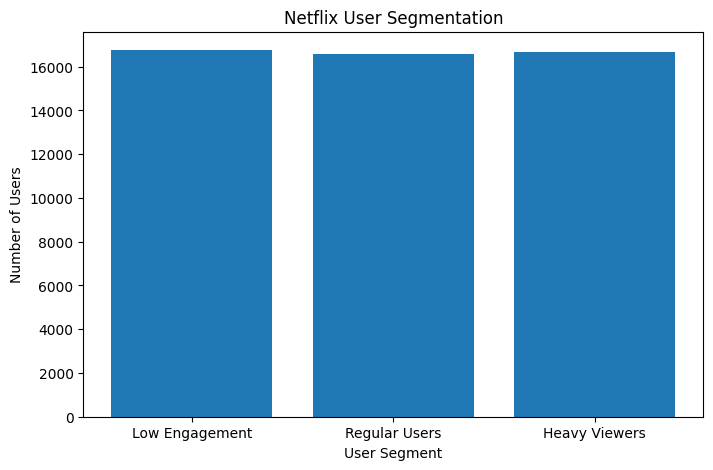

In [0]:
import matplotlib.pyplot as plt

segment_count = (
    df_final
    .groupBy("User_Segment")
    .count()
    .toPandas()
)

plt.figure(figsize=(8,5))

plt.bar(
    segment_count["User_Segment"],
    segment_count["count"]
)

plt.xlabel("User Segment")
plt.ylabel("Number of Users")
plt.title("Netflix User Segmentation")

plt.show()

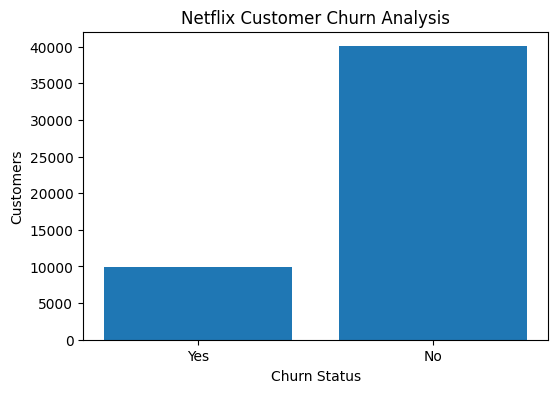

In [0]:
import matplotlib.pyplot as plt

churn_data = (
    df_final
    .groupBy("churned")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    churn_data["churned"].astype(str),
    churn_data["count"]
)

plt.xlabel("Churn Status")
plt.ylabel("Customers")
plt.title("Netflix Customer Churn Analysis")

plt.show()

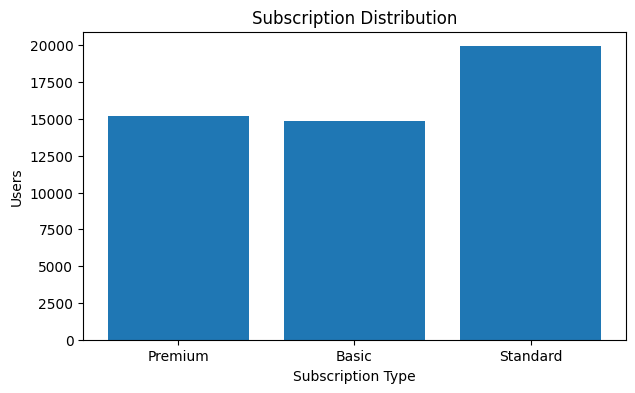

In [0]:
subscription_data = (
    df_final
    .groupBy("subscription_type")
    .count()
    .toPandas()
)

plt.figure(figsize=(7,4))

plt.bar(
    subscription_data["subscription_type"],
    subscription_data["count"]
)

plt.xlabel("Subscription Type")
plt.ylabel("Users")
plt.title("Subscription Distribution")

plt.show()

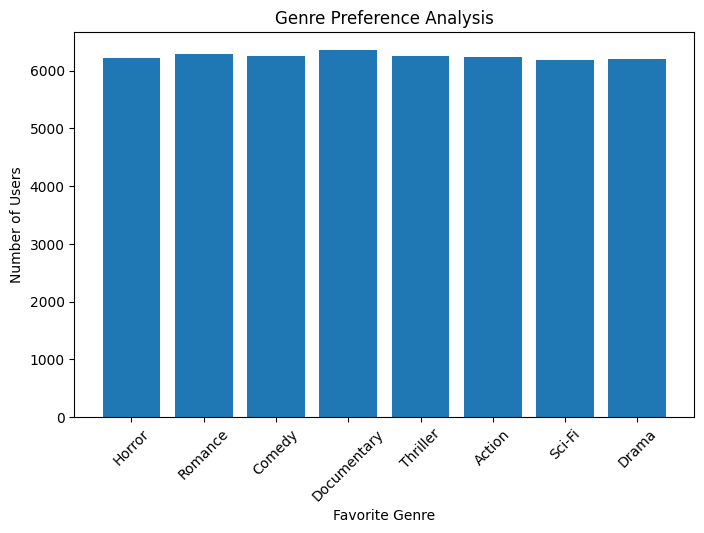

In [0]:
import matplotlib.pyplot as plt

genre_count = (
    df_final
    .groupBy("favorite_genre")
    .count()
    .toPandas()
)

plt.figure(figsize=(8,5))

plt.bar(
    genre_count["favorite_genre"],
    genre_count["count"]
)

plt.xlabel("Favorite Genre")
plt.ylabel("Number of Users")
plt.title("Genre Preference Analysis")

plt.xticks(rotation=45)

plt.show()

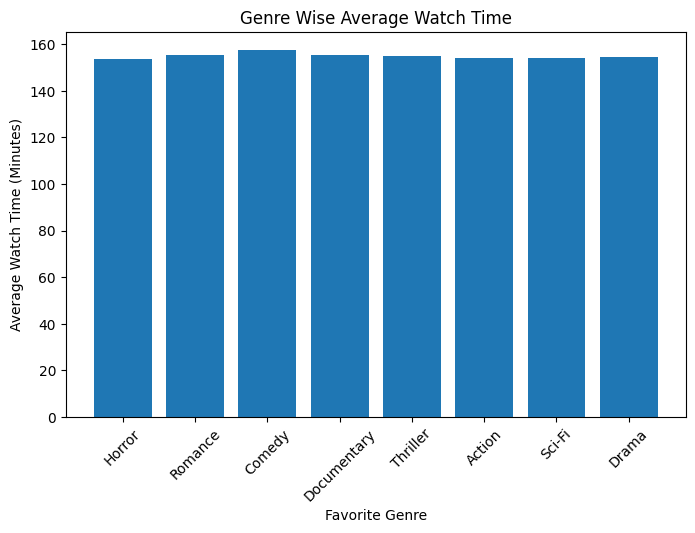

In [0]:
import matplotlib.pyplot as plt

watch_data = (
    df_final
    .groupBy("favorite_genre")
    .avg("avg_watch_time_minutes")
    .toPandas()
)

plt.figure(figsize=(8,5))

plt.bar(
    watch_data["favorite_genre"],
    watch_data["avg(avg_watch_time_minutes)"]
)

plt.xlabel("Favorite Genre")
plt.ylabel("Average Watch Time (Minutes)")
plt.title("Genre Wise Average Watch Time")

plt.xticks(rotation=45)

plt.show()

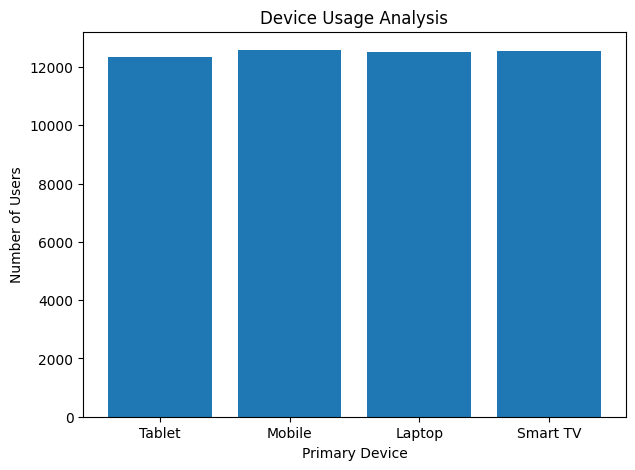

In [0]:
import matplotlib.pyplot as plt

device_count = (
    df_final
    .groupBy("primary_device")
    .count()
    .toPandas()
)

plt.figure(figsize=(7,5))

plt.bar(
    device_count["primary_device"],
    device_count["count"]
)

plt.xlabel("Primary Device")
plt.ylabel("Number of Users")
plt.title("Device Usage Analysis")

plt.show()

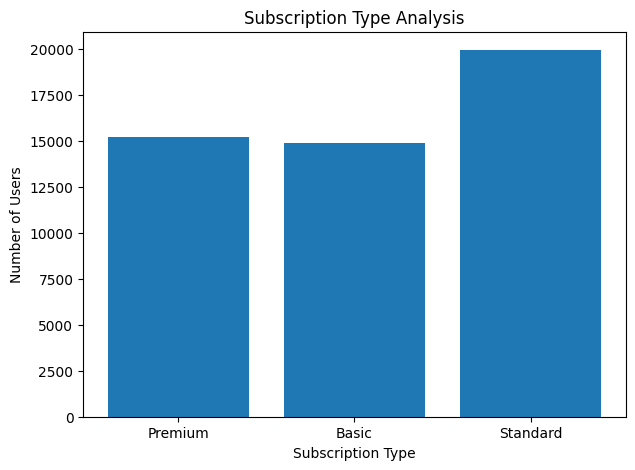

In [0]:
import matplotlib.pyplot as plt

subscription_count = (
    df_final
    .groupBy("subscription_type")
    .count()
    .toPandas()
)

plt.figure(figsize=(7,5))

plt.bar(
    subscription_count["subscription_type"],
    subscription_count["count"]
)

plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")
plt.title("Subscription Type Analysis")

plt.show()

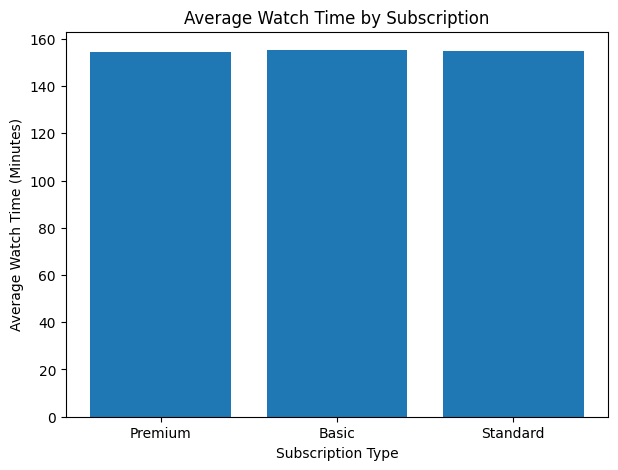

In [0]:
import matplotlib.pyplot as plt

watch_time = (
    df_final
    .groupBy("subscription_type")
    .avg("avg_watch_time_minutes")
    .toPandas()
)

plt.figure(figsize=(7,5))

plt.bar(
    watch_time["subscription_type"],
    watch_time["avg(avg_watch_time_minutes)"]
)

plt.xlabel("Subscription Type")
plt.ylabel("Average Watch Time (Minutes)")
plt.title("Average Watch Time by Subscription")

plt.show()

In [0]:
df_powerbi = df_final.drop("features")

In [0]:
df_powerbi.write \
.mode("overwrite") \
.option("header", True) \
.csv("/Volumes/workspace/default/netflix_data/netflix_powerbi_output")

In [0]:
display(dbutils.fs.ls("/Volumes/workspace/default/netflix_data/netflix_powerbi_output"))

path,name,size,modificationTime
dbfs:/Volumes/workspace/default/netflix_data/netflix_powerbi_output/_SUCCESS,_SUCCESS,0,1782568532000
dbfs:/Volumes/workspace/default/netflix_data/netflix_powerbi_output/_committed_1799108501649121430,_committed_1799108501649121430,202,1782568532000
dbfs:/Volumes/workspace/default/netflix_data/netflix_powerbi_output/_started_1799108501649121430,_started_1799108501649121430,0,1782568532000
dbfs:/Volumes/workspace/default/netflix_data/netflix_powerbi_output/part-00000-tid-1799108501649121430-fcc8d02f-6dcc-4529-9268-4fc94aa0f20f-859-1-c000.csv,part-00000-tid-1799108501649121430-fcc8d02f-6dcc-4529-9268-4fc94aa0f20f-859-1-c000.csv,2750425,1782568532000
dbfs:/Volumes/workspace/default/netflix_data/netflix_powerbi_output/part-00001-tid-1799108501649121430-fcc8d02f-6dcc-4529-9268-4fc94aa0f20f-860-1-c000.csv,part-00001-tid-1799108501649121430-fcc8d02f-6dcc-4529-9268-4fc94aa0f20f-860-1-c000.csv,2711282,1782568532000


In [0]:
%whos

Variable   Type            Data/Info
------------------------------------
spark      SparkSession    <pyspark.sql.connect.sess<...>object at 0xffe1cd34e3c0>
sql        method          <bound method SparkSessio<...>bject at 0xffe1cd34e3c0>>
table      method          <bound method SparkSessio<...>bject at 0xffe1cd34e3c0>>


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

In [0]:
features = [
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "binge_watch_sessions",
    "completion_rate",
    "rating_given"
]

In [0]:
df = spark.read.csv(
    "/Volumes/workspace/default/netflix_data/netflix_user_behavior_dataset.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-------+---+------+-------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|user_id|age|gender|country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|
+-------+---+------+-------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|U100000| 56|  Male|  India|                17|         Standard|     

In [0]:
df_clean = df.dropna().dropDuplicates()

df_clean.show(5)

+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|user_id|age|gender|  country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|
+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+
|U100008| 40|Female|Australia|                20|            Bas

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

features = [
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "binge_watch_sessions",
    "completion_rate",
    "rating_given"
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

df_ml = assembler.transform(df_clean)


kmeans = KMeans(
    k=3,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

model = kmeans.fit(df_ml)

df_clustered = model.transform(df_ml)

In [0]:
from pyspark.sql.functions import when

df_final = df_clustered.withColumn(
    "User_Segment",
    when(df_clustered.cluster == 0, "Low Engagement")
    .when(df_clustered.cluster == 1, "Regular Users")
    .otherwise("Heavy Viewers")
)

df_final.show(5)

+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+---------------------+-------+--------------------+-------+--------------+
|user_id|age|gender|  country|account_age_months|subscription_type|monthly_fee|payment_method|primary_device|devices_used|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|binge_watch_sessions|completion_rate|rating_given|content_interactions|recommendation_click_rate|days_since_last_login|churned|            features|cluster|  User_Segment|
+-------+---+------+---------+------------------+-----------------+-----------+--------------+--------------+------------+--------------+----------------------+-----------------------+--------------------+---------------+------------+--------------------+-------------------------+-------

In [0]:
df_powerbi = df_final.drop("features")

In [0]:
df_powerbi = df_powerbi.select(
    "user_id",
    "Age",
    "gender",
    "country",
    "subscription_type",
    "favorite_genre",
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "churned",
    "User_Segment"
)

df_powerbi.show(5)

+-------+---+------+---------+-----------------+--------------+----------------------+-----------------------+-------+--------------+
|user_id|Age|gender|  country|subscription_type|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|churned|  User_Segment|
+-------+---+------+---------+-----------------+--------------+----------------------+-----------------------+-------+--------------+
|U100008| 40|Female|Australia|            Basic|       Romance|                   202|                      7|     No|Low Engagement|
|U100012| 53|  Male|Australia|         Standard|   Documentary|                    42|                     18|    Yes| Regular Users|
|U100018| 41|Female|   Brazil|         Standard|        Comedy|                   219|                     19|     No| Heavy Viewers|
|U100053| 61|  Male|   France|            Basic|         Drama|                   217|                     13|     No| Heavy Viewers|
|U100075| 32| Other|   Canada|          Premium|        Action

In [0]:
df_powerbi = df_powerbi.select(
    "user_id",
    "Age",
    "gender",
    "country",
    "subscription_type",
    "favorite_genre",
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "churned",
    "User_Segment"
)

df_powerbi.show(5)

+-------+---+------+---------+-----------------+--------------+----------------------+-----------------------+-------+--------------+
|user_id|Age|gender|  country|subscription_type|favorite_genre|avg_watch_time_minutes|watch_sessions_per_week|churned|  User_Segment|
+-------+---+------+---------+-----------------+--------------+----------------------+-----------------------+-------+--------------+
|U100008| 40|Female|Australia|            Basic|       Romance|                   202|                      7|     No|Low Engagement|
|U100012| 53|  Male|Australia|         Standard|   Documentary|                    42|                     18|    Yes| Regular Users|
|U100018| 41|Female|   Brazil|         Standard|        Comedy|                   219|                     19|     No| Heavy Viewers|
|U100053| 61|  Male|   France|            Basic|         Drama|                   217|                     13|     No| Heavy Viewers|
|U100075| 32| Other|   Canada|          Premium|        Action

In [0]:
df_powerbi.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("/Volumes/workspace/default/netflix_data/netflix_dashboard_final")

In [0]:
display(
    dbutils.fs.ls("/Volumes/workspace/default/netflix_data/netflix_dashboard_final")
)

path,name,size,modificationTime
dbfs:/Volumes/workspace/default/netflix_data/netflix_dashboard_final/_SUCCESS,_SUCCESS,0,1782569869000
dbfs:/Volumes/workspace/default/netflix_data/netflix_dashboard_final/_committed_1357472772233128147,_committed_1357472772233128147,114,1782569869000
dbfs:/Volumes/workspace/default/netflix_data/netflix_dashboard_final/_started_1357472772233128147,_started_1357472772233128147,0,1782569868000
dbfs:/Volumes/workspace/default/netflix_data/netflix_dashboard_final/part-00000-tid-1357472772233128147-64f88d53-174e-4d38-b5fc-dc2cecf7c57e-1047-1-c000.csv,part-00000-tid-1357472772233128147-64f88d53-174e-4d38-b5fc-dc2cecf7c57e-1047-1-c000.csv,3142423,1782569869000
